In [40]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import os

!unzip -q "/content/drive/MyDrive/fruits-360_100x100.zip" -d "/content/dataset/"

dataset_path = "/content/dataset/fruits-360/Training"

print("Detected classes:", len(os.listdir(dataset_path)))
import tensorflow as tf
print(tf.config.list_physical_devices())

replace /content/dataset/fruits-360/LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Detected classes: 250
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


EDA and visualisation :

Total Classes: 250 
Class Names: ['Tomato 5', 'Beetroot 1', 'Pomegranate 1', 'Apple 5', 'Pear 2', 'Raspberry 2', 'Pear 3', 'Potato Red 2', 'Grapefruit White 1', 'Apple Red Delicious 1', 'Strawberry 2', 'Apple Granny Smith 1', 'Cherry Wax Red 2', 'Bean pod 1', 'Zucchini 1', 'Peach 1', 'Pineapple 1', 'Tomato 3', 'Tomato Cherry Red 1', 'Maracuja 1', 'Nut 2', 'Apple Braeburn 1', 'Apple 8', 'Potato Sweet 1', 'Cabbage red 1', 'Pear Williams 1', 'Grape Blue 1', 'Peanut shell 1x 1', 'Blueberry 1', 'Papaya 1', 'Cherry 2', 'Nut Forest 1', 'Cherry 1', 'Pear 14', 'Cherry Rainier 1', 'Quince 4', 'Cucumber 13', 'Cherry Wax 2', 'Plum 5', 'Onion Red 3', 'Pepper Red 2', 'Passion Fruit 1', 'Raspberry 3', 'Pear Kaiser 1', 'Apple Pink Lady 1', 'Cherry 5', 'Apple Golden 1', 'Corn 1', 'Onion White 2', 'Guava 1', 'Pear 7', 'Pepino 1', 'Banana 1', 'Pepper Red 5', 'Tomato Cherry Maroon 1', 'Apple 7', 'Banana 3', 'Apple 22', 'Corn Husk 1', 'Cauliflower 1', 'Cabbage white 1', 'Kumquats 1', 'Peach 5', 'Quince 3',

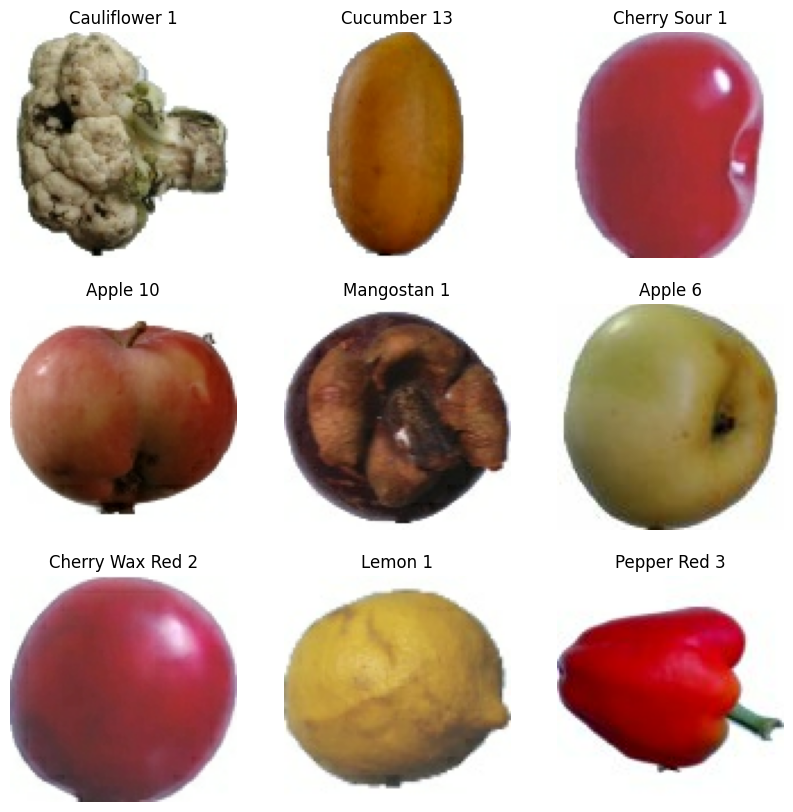

In [42]:
import matplotlib.pyplot as plt
import tensorflow as tf
import os

classes = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print(f"Total Classes: {len(classes)} \nClass Names: {classes}")

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(100,100),
    batch_size=9
)

plt.figure(figsize=(10, 10))
for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds_raw.class_names[labels[i]])
        plt.axis("off")

In [43]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(100,100),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(100,100),
    batch_size=32
)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 130344 files belonging to 250 classes.
Using 104276 files for training.
Found 130344 files belonging to 250 classes.
Using 26068 files for validation.


In [44]:
import os

print("Items found in dataset_path:", os.listdir(dataset_path))

classes = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print("Detected Classes:", classes)
print("Total Class Count:", len(classes))

Items found in dataset_path: ['Tomato 5', 'Beetroot 1', 'Pomegranate 1', 'Apple 5', 'Pear 2', 'Raspberry 2', 'Pear 3', 'Potato Red 2', 'Grapefruit White 1', 'Apple Red Delicious 1', 'Strawberry 2', 'Apple Granny Smith 1', 'Cherry Wax Red 2', 'Bean pod 1', 'Zucchini 1', 'Peach 1', 'Pineapple 1', 'Tomato 3', 'Tomato Cherry Red 1', 'Maracuja 1', 'Nut 2', 'Apple Braeburn 1', 'Apple 8', 'Potato Sweet 1', 'Cabbage red 1', 'Pear Williams 1', 'Grape Blue 1', 'Peanut shell 1x 1', 'Blueberry 1', 'Papaya 1', 'Cherry 2', 'Nut Forest 1', 'Cherry 1', 'Pear 14', 'Cherry Rainier 1', 'Quince 4', 'Cucumber 13', 'Cherry Wax 2', 'Plum 5', 'Onion Red 3', 'Pepper Red 2', 'Passion Fruit 1', 'Raspberry 3', 'Pear Kaiser 1', 'Apple Pink Lady 1', 'Cherry 5', 'Apple Golden 1', 'Corn 1', 'Onion White 2', 'Guava 1', 'Pear 7', 'Pepino 1', 'Banana 1', 'Pepper Red 5', 'Tomato Cherry Maroon 1', 'Apple 7', 'Banana 3', 'Apple 22', 'Corn Husk 1', 'Cauliflower 1', 'Cabbage white 1', 'Kumquats 1', 'Peach 5', 'Quince 3', 'Cu

In [45]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(100, 100, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=15)

Epoch 1/15
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.3953 - loss: 2.6120 - val_accuracy: 0.9615 - val_loss: 0.1057
Epoch 2/15
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - accuracy: 0.8336 - loss: 0.4933 - val_accuracy: 0.9786 - val_loss: 0.0490
Epoch 3/15
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - accuracy: 0.8905 - loss: 0.3126 - val_accuracy: 0.9839 - val_loss: 0.0324
Epoch 4/15
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 52s 16ms/step - accuracy: 0.9122 - loss: 0.2446 - val_accuracy: 0.9864 - val_loss: 0.0296
Epoch 5/15
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - accuracy: 0.9275 - loss: 0.2034 - val_accuracy: 0.9849 - val_loss: 0.0287
Epoch 6/15
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - accuracy: 0.9406 - loss: 0.1658 - val_accuracy: 0.9873 - val_loss: 0.0221
Epoch 7/15
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 51s 16ms/step - accuracy: 0.9483 - loss: 0.1456 - val_accuracy: 0.9891 - val_loss: 0.0233
Epoch 8/15
3259/3259 ━━━━━━━━━━━━━━━━━━━━ 77s 14ms/step - accuracy: 0.9523 -

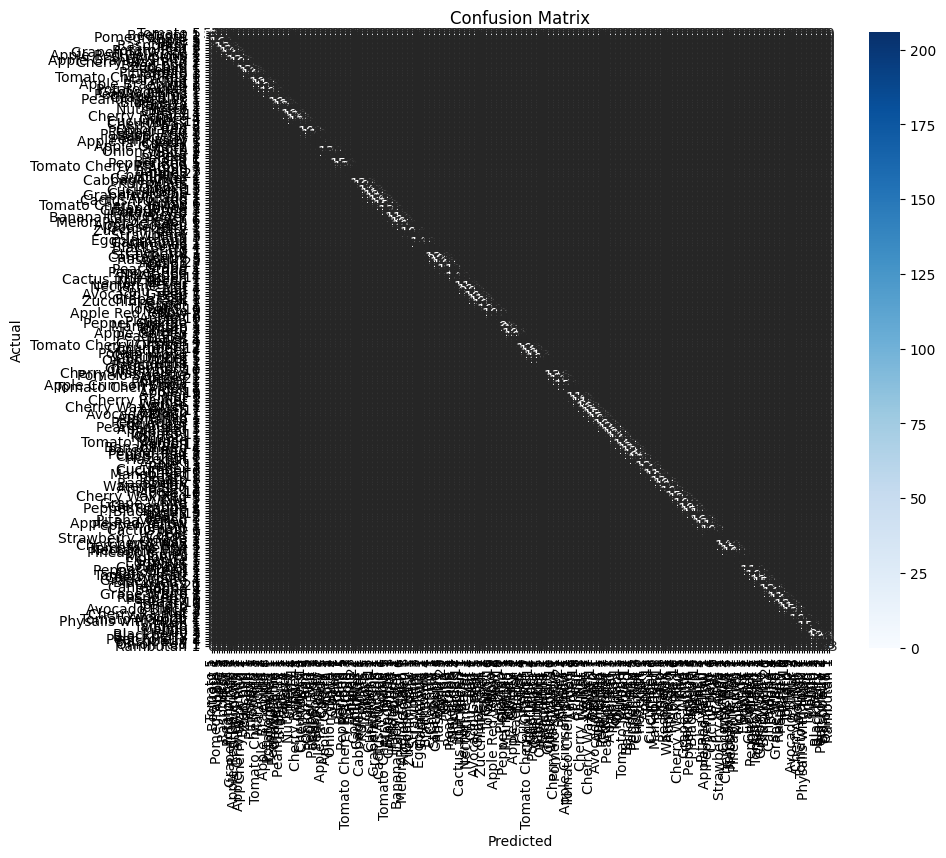

In [46]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(model.predict(images, verbose=0), axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

In [47]:
model.save("fruit_model.keras")

def predict_fruit(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(100, 100))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0

    pred = model.predict(img_array, verbose=0)
    print(f"Prediction: {classes[np.argmax(pred)]} ({100*np.max(pred):.2f}%)")



Found 130344 files belonging to 250 classes.
Using 104276 files for training.
Classes loaded: 250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step


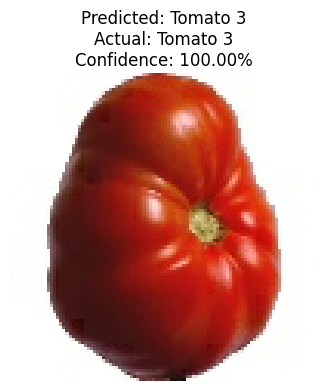

Predicted: Tomato 3
Actual: Tomato 3
Confidence: 100.00%


In [49]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


model = tf.keras.models.load_model("fruit_model.keras")

base_folder = os.listdir("/content/dataset")[0]
dataset_path = f"/content/dataset/{base_folder}/Training"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(100,100),
    batch_size=64
)

class_names = train_ds.class_names
print("Classes loaded:", len(class_names))

for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    break

img = np.expand_dims(sample_image, axis=0)
prediction = model.predict(img)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

plt.figure(figsize=(4,4))
plt.imshow(sample_image.numpy().astype("uint8"))
plt.axis("off")

plt.title(f"Predicted: {class_names[predicted_class]}\n"
          f"Actual: {class_names[sample_label]}\n"
          f"Confidence: {confidence:.2f}%")

plt.show()

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[sample_label])
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


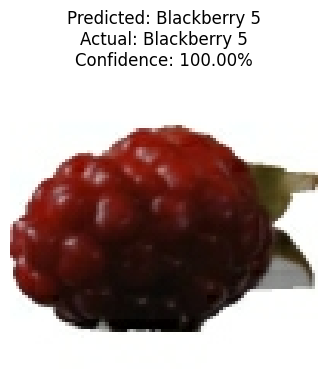

Predicted: Blackberry 5
Actual: Blackberry 5
Confidence: 100.00%


In [52]:
import matplotlib.pyplot as plt
import numpy as np


for images, labels in train_ds.take(1):
    sample_image = images[8]
    sample_label = labels[8]
    break


img = np.expand_dims(sample_image, axis=0)
prediction = model.predict(img)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

plt.figure(figsize=(4,4))
plt.imshow(sample_image.numpy().astype("uint8"))
plt.axis("off")

plt.title(f"Predicted: {class_names[predicted_class]}\n"
          f"Actual: {class_names[sample_label]}\n"
          f"Confidence: {confidence:.2f}%")

plt.show()


print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[sample_label])
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


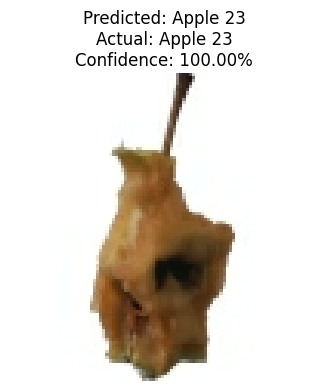

Predicted: Apple 23
Actual: Apple 23
Confidence: 100.00%


In [53]:
import matplotlib.pyplot as plt
import numpy as np


for images, labels in train_ds.take(1):
    sample_image = images[10]
    sample_label = labels[10]
    break


img = np.expand_dims(sample_image, axis=0)
prediction = model.predict(img)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

plt.figure(figsize=(4,4))
plt.imshow(sample_image.numpy().astype("uint8"))
plt.axis("off")

plt.title(f"Predicted: {class_names[predicted_class]}\n"
          f"Actual: {class_names[sample_label]}\n"
          f"Confidence: {confidence:.2f}%")

plt.show()


print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[sample_label])
print(f"Confidence: {confidence:.2f}%")

In [54]:
from google.colab import files
files.download("fruit_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>